## Clasificación de MRI con Redes Neuronales Convolucionales para Tipos de Cáncer

In [18]:
# Importar librerías necesárias para el desarrollo del ejercicio

import kagglehub
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import itertools
import shutil

In [3]:
#Se importan los datos desde la ruta establecida.
#Este conjunto de datos contiene 7023 imágenes extraídas de MRIs tomados desde distintos ángulos y disponibles para dominio público.

import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 236M/236M [03:45<00:00, 1.10MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\rm1000\brain-tumor-mri-scans\versions\1


In [11]:
# Definir rutas a Training y Testing
train_dir = os.path.join(path, "Training")
test_dir = os.path.join(path, "Testing")

## Categorías Presentadas en el Conjunto de Datos

En el dataset de Kaggle “Brain Tumor MRI Scans” (rm1000/brain-tumor-mri-scans), las cuatro clases principales se identifican directamente por las carpetas contenidas en los subdirectorios Training/ y Testing/.
La clase y descripción de las categorías obedecen a:

**Glioma**: Tumor que se origina en las células gliales del cerebro o médula espinal. Es el tipo más común de tumor cerebral maligno.

**Meningioma**: Tumor que surge de las meninges (membranas que rodean el cerebro y médula espinal). Generalmente benigno.

**Pituitary**: Tumor localizado en la glándula pituitaria (hipófisis), puede afectar el equilibrio hormonal.

**Notumor**: Imágenes de MRI de cerebros sin presencia de tumor (casos saludables).

Para el desarrollo del ejercicio nos enfocaremos en el modelo de detección de gliomas, es decir: clasificar imágenes como “glioma” vs “no glioma” (clasificación binaria).

In [16]:
#Creación de Carpetas Binarias (Glioma , No Glioma)
#Se quiere que el modelo vea sólo dos (2) clases: Clase 1: Glioma, Clase 2: No Glioma

src_dir = path  # Se direcciona a las carpetas ['glioma', 'healthy', 'meningioma', 'pituitary']

# Carpeta destino para nuestro dataset binario
binary_dataset = "binary_brain_tumor_dataset"
train_ratio = 0.8  # 80% entrenamiento, 20% para prueba

# Crear estructura
for split in ["Training", "Testing"]:
    for cls in ["glioma", "no_glioma"]:
        os.makedirs(os.path.join(binary_dataset, split, cls), exist_ok=True)

# Clasificar imágenes en glioma y no_glioma
for cls in os.listdir(src_dir):
    cls_path = os.path.join(src_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    
    # Asignar clase destino
    target_class = "glioma" if cls.lower() == "glioma" else "no_glioma"
    images = os.listdir(cls_path)
    
    # División 80/20
    split_idx = int(len(images) * train_ratio)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]
    
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(binary_dataset, "Training", target_class, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(binary_dataset, "Testing", target_class, img))

print("Dataset binario creado exitosamente en:", binary_dataset)


Dataset binario creado exitosamente en: binary_brain_tumor_dataset


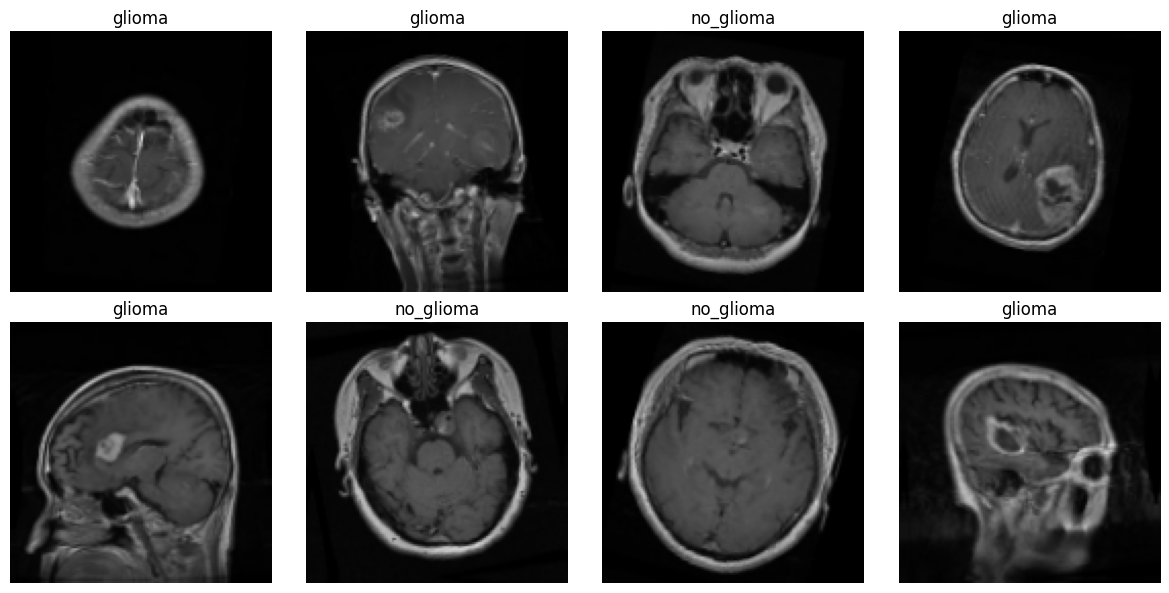

In [28]:
# Visualización de imágenes aleatorias del conjunto de datos
# -------------------------------
def show_random_images(dataset, class_names, num_images=8):
    plt.figure(figsize=(12, 6))
    for images, labels in dataset.take(1):
        indices = np.random.choice(range(len(images)), num_images, replace=False)
        for i, idx in enumerate(indices):
            ax = plt.subplot(2, 4, i + 1)

            # Convertir valores [0,1] → [0,255] para visualización
            img = images[idx].numpy()
            if img.max() <= 1.0:  # si está normalizada
                img = (img * 255).astype("uint8")
            else:
                img = img.astype("uint8")

            label = int(labels[idx].numpy().item())

            plt.imshow(img)
            plt.title(f"{class_names[label]}")
            plt.xlabel(f"{img.shape[0]}x{img.shape[1]}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Ejecutar visualización
show_random_images(train_ds, class_names)



In [20]:
#Carga del Conjunto de Dtaos y Preparación del PipeLine

# Configuración Básica
# -------------------------------
IMG_SIZE = (128, 128)               #Define el tamaño al que se redimensionará la imagen antes de entrar a la red Neuronal
BATCH_SIZE = 32                     #Indica cuántas imágenes se procesarán en cada paso de entrenamiento
SEED = 42                           #Semilla aleatoria para garantizar la reproductibilidad
AUTOTUNE = tf.data.AUTOTUNE         #Es una optimización automática de TF para cargar los datos de forma más rápida

# -------------------------------
# CARGA DE DATOS
# -------------------------------
train_dir = os.path.join(binary_dataset, "Training")
test_dir = os.path.join(binary_dataset, "Testing")

# Dataset de entrenamiento y validación (usamos validation_split=0.2)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',       # solo 2 clases
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset='training'          # conjunto de entrenamiento
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset='validation'        # conjunto de validación
)

# Dataset de prueba (Testing)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Mostrar nombres de clases detectadas
class_names = train_ds.class_names
print("Clases detectadas:", class_names)

# -------------------------------
# PREPROCESAMIENTO Y MEJORAS DE RENDIMIENTO
# -------------------------------
# Normalización [0,1]
normalization = layers.Rescaling(1./255)

# Aumento de datos (solo para entrenamiento)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

# Función para preparar datasets
def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.prefetch(buffer_size=AUTOTUNE)

# Aplicar preparación
train_ds = prepare(train_ds, augment=True, shuffle=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

print("Datasets preparados correctamente.")


Found 2896 files belonging to 2 classes.
Using 2317 files for training.
Found 2896 files belonging to 2 classes.
Using 579 files for validation.
Found 1009 files belonging to 2 classes.
Clases detectadas: ['glioma', 'no_glioma']
Datasets preparados correctamente.


## CONSTRUCCIÓN Y ENTRENAMIENTO DE LA CNN

El desarrollo de este bloque se realizará en dos (2) partes.

**Parte 1**: Definición de la arquitectura (Capas Convolucionales, pooling)

**Parte 2**: Compilar y entrenar el modelo con los datos (train_de, val_ds)

In [21]:
# Arquitectura de la CNN
# -------------------------------
def build_binary_cnn(input_shape=(128, 128, 3)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Bloque 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Bloque 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Bloque 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Aplanado y capas densas
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),

        # Capa de salida binaria
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Crear modelo
model = build_binary_cnn()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compilación del modelo
# -------------------------------
#Para este caso, se usará:

#Adam: optimizador adaptativo eficiente para CNNs.
#binary_crossentropy: pérdida usada para clasificación binaria (glioma vs no_glioma).
#accuracy: métrica general de rendimiento.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',   # Porque solo hay 2 clases
    metrics=['accuracy']
)

In [25]:
#Entrenamiento del Modelo

#-------------------------

EPOCHS = 20                # Número de épocas

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 32s 367ms/step - accuracy: 0.8800 - loss: 0.3024 - val_accuracy: 0.9240 - val_loss: 0.2054
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 312ms/step - accuracy: 0.9348 - loss: 0.1731 - val_accuracy: 0.9188 - val_loss: 0.2264
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 318ms/step - accuracy: 0.9461 - loss: 0.1489 - val_accuracy: 0.9655 - val_loss: 0.1029
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 312ms/step - accuracy: 0.9594 - loss: 0.1034 - val_accuracy: 0.9793 - val_loss: 0.0567
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 345ms/step - accuracy: 0.9702 - loss: 0.0792 - val_accuracy: 0.9672 - val_loss: 0.0753
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 344ms/step - accuracy: 0.9685 - loss: 0.0862 - val_accuracy: 0.9620 - val_loss: 0.0851
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 29s 363ms/step - accuracy: 0.9741 - loss: 0.0830 - val_accuracy: 0.9603 - val_loss: 0.1000
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 330ms/step - accuracy: 0.9789 - loss: 0.0619 - val_accu

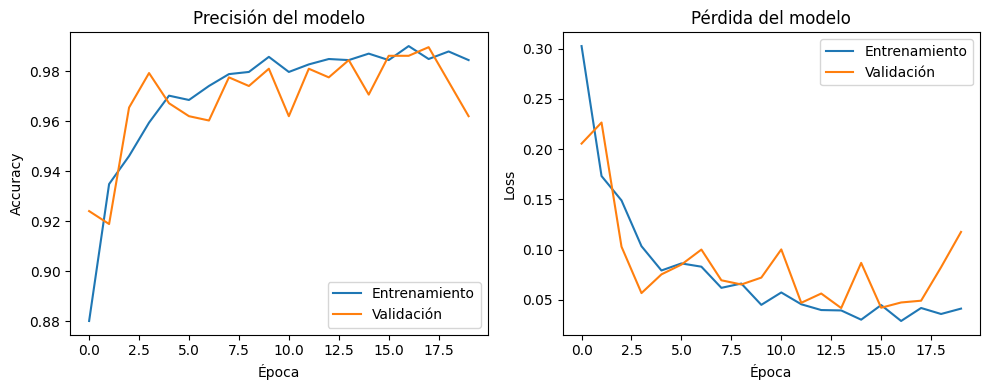

In [29]:
#Visualización de las Curvas de Entrenamiento
# -------------------------------
# Curvas de pérdida y exactitud
# -------------------------------
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Algunos comentarios sobre las etapas de entrenamiento y validación.

Precisión del Modelo:

**1:** Desde las primeras épocas, la precisión sube rápidamente de ~0.88 a >0.95.

**2:** Ambas curvas se mantienen muy cercanas durante todo el entrenamiento.

**3:** Hacia las últimas épocas, la validación incluso supera ligeramente al entrenamiento en algunos punto

De lo anterior: El modelo está aprendiendo bien las características relevantes de las imágenes MRI. No hay sobreajuste significativo, ya que las dos curvas son similares (no se separan ampliamente).

Pérdida del Modelo:

**1:** Al inicio, las pérdidas son altas (entorno a 0.3). Ambas bajan rápidamente durante las primeras 3–5 épocas.

**2:** Estabilización de 0.05–0.1, con ligeras fluctuaciones. Al final, la pérdida de validación sube un poco, mientras la de entrenamiento sigue bajando.

De lo anterior se puede inferir: El descenso inicial muestra que el modelo aprende efectivamente. El ligero aumento al final en la pérdida de validación podría indicar inicio leve de sobreajuste, pero no es grave (porque la precisión de validación sigue alta).


In [31]:
#Se guarda el modelo entrenado
model.save("cnn_glioma_detector.h5")
print("Modelo guardado como cnn_glioma_detector.h5")


Modelo guardado como cnn_glioma_detector.h5


In [32]:
#Evaluación del modelo ya Entrenado

# -------------------------------
# Evaluación general en el conjunto de Prueba
# -------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Pérdida (loss) en test: {test_loss:.4f}")
print(f" Precisión (accuracy) en test: {test_acc:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.9237 - loss: 0.4266 

 Pérdida (loss) en test: 0.4266
 Precisión (accuracy) en test: 0.9237


In [33]:
# -------------------------------
# Predicciones y etiquetas reales
# -------------------------------
y_true = []
y_pred = []

for images, labels in test_ds:
    probs = model.predict(images)
    preds = (probs.flatten() > 0.5).astype(int)   # Umbral de 0.5
    y_pred.extend(preds)
    y_true.extend(labels.numpy().astype(int))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Matriz de confusión:
 [[297  28]
 [ 49 635]]


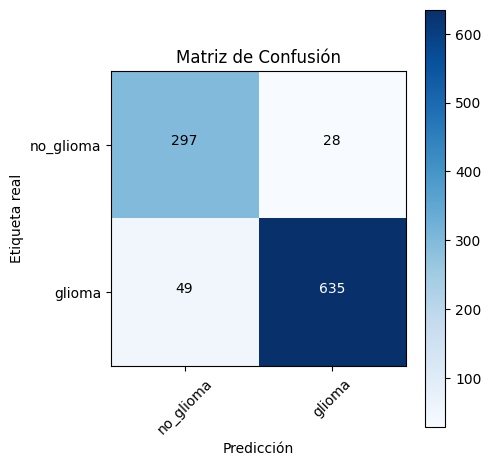

In [34]:
# Matriz de confusión
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
classes = ['no_glioma', 'glioma']
print("Matriz de confusión:\n", cm)

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Etiqueta real')
    plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes)


In [35]:
# Métricas detalladas
# -------------------------------
report = classification_report(y_true, y_pred, target_names=classes, digits=4)
print("Reporte de clasificación:\n", report)


Reporte de clasificación:
               precision    recall  f1-score   support

   no_glioma     0.8584    0.9138    0.8852       325
      glioma     0.9578    0.9284    0.9428       684

    accuracy                         0.9237      1009
   macro avg     0.9081    0.9211    0.9140      1009
weighted avg     0.9258    0.9237    0.9243      1009



### Análisis Métricas Detalladas

**Clase No Glioma** 

-Precision: 0.8584. De todas las imágenes que el modelo presenta “no_glioma”, el 85.8% eran realmente no_glioma.

-Recall: 0.9138. De todas las imágenes no_glioma reales, el modelo reconoció correctamente el 91.3%.

-F1-score = 0.8852. Balance bueno entre precisión y recall.

-Suppport = 325. Había 325 imágenes sin glioma.

El modelo detecta bien los no_glioma (alto recall), aunque a veces confunde algunas con glioma (precision algo menor).
Esto indica que el modelo tiende ligeramente a “sobre-diagnosticar” glioma, lo cual, en medicina, puede ser preferible (prefiere falsos positivos antes que falsos negativos).

**Clase Glioma** 

-Precision: 0.9578. De todas las imágenes clasificadas como “glioma”, el 95.8% son correctas.

-Recall: 0.9284. Detecta correctamente el 92.8% de los casos reales de glioma.

-F1-score = 0.9428. Balance bueno entre precisión y recall.

-Suppport = 684. Clase mayoritaria en el dataset.

**Métricas Globales**

-Accuracy = 0.9237 (92.37%). El modelo acierta en 9 de cada 10 imágenes.	

-Macro avg (0.9140). Promedio simple entre ambas clases (pondera igual no_glioma y glioma).	

-Weighted avg (0.9243). Promedio ponderado según el número de imágenes por clase (más realista).

**Interpretación General**

-Ambas clases están muy balanceadas en desempeño (diferencias < 10%).

-El modelo muestra consistencia y estabilidad: ni sesgo fuerte hacia una clase, ni pérdida de generalización.

-Con una accuracy total del 92.37%, está en un rango adecuado para imágenes médicas reales.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


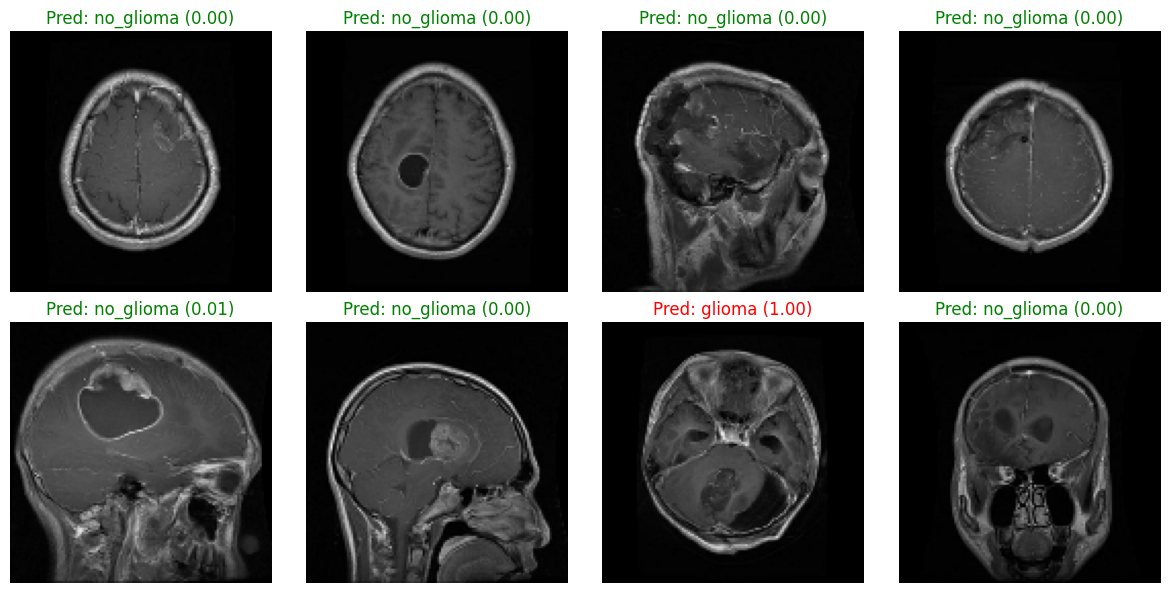

In [38]:
def show_predictions(dataset, model, class_names, num_images=8):
    plt.figure(figsize=(12, 6))
    for images, labels in dataset.take(1):
        probs = model.predict(images).flatten()
        indices = np.random.choice(range(len(images)), num_images, replace=False)
        for i, idx in enumerate(indices):
            ax = plt.subplot(2, 4, i + 1)
            img = images[idx].numpy()
            if img.max() <= 1.0:
                img = (img * 255).astype("uint8")
            plt.imshow(img)
            true_label = int(labels[idx].numpy().item())
            pred_prob = probs[idx]
            pred_label = int(pred_prob > 0.5)
            color = "green" if true_label == pred_label else "red"
            plt.title(f"Pred: {class_names[pred_label]} ({pred_prob:.2f})", color=color)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(test_ds, model, classes)


## Concluiones Técnicas y Clínicas

**En términos técnicos:**

La CNN alcanza una precisión global del 92% y un F1 promedio de 0.91, mostrando un equilibrio entre sensibilidad y especificidad. No hay evidencia de sobreentrenamiento ni de colapso de clases.

**En términos clínicos:**

El modelo es confiable para detectar gliomas en imágenes MRI y comete pocos falsos negativos (riesgo clínico bajo). El pequeño exceso de falsos positivos (confundir algunos no_glioma como glioma) es aceptable y puede corregirse con un ajuste del umbral o balanceo de clases.

## Algunas Recomendaciones

-Para la Clase minoritaria (no_glioma) se presenta menor precisión identificando algunos falsos positivos.Para este caso en particular, se podría revisar si el conjunto de datos está balanceado. Si no, aplicar class_weight o data augmentation adicional en “no_glioma”.

-En el caso  de la clase mayoritaria (glioma) se presenta buena precisión y recall. En este caso se podría mantener arquitectura, quizás ajustar dropout para afinar recall.

In [39]:
# Obtener probabilidades reales del modelo
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = model.predict(images).flatten()
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy().astype(int))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

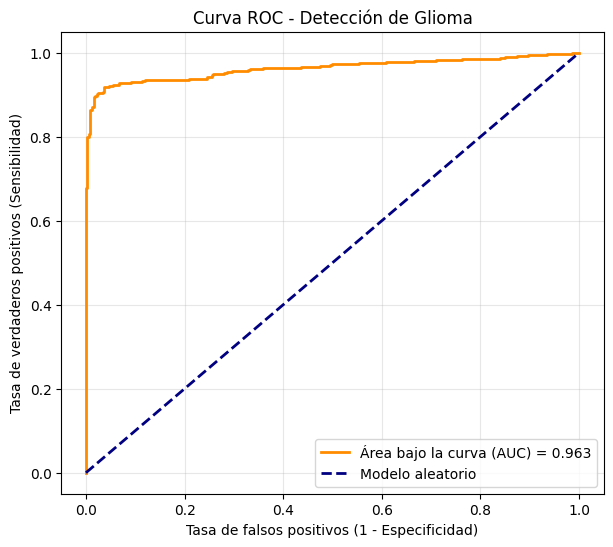

In [42]:
# Curva ROC
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Área bajo la curva (AUC) = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo aleatorio')
plt.xlabel('Tasa de falsos positivos (1 - Especificidad)')
plt.ylabel('Tasa de verdaderos positivos (Sensibilidad)')
plt.title('Curva ROC - Detección de Glioma')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [43]:
# -------------------------------
# Umbral óptimo (Youden’s J)
# -------------------------------
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"🔹 Umbral óptimo: {optimal_threshold:.3f}")
print(f"🔹 Sensibilidad (TPR): {tpr[optimal_idx]:.3f}")
print(f"🔹 Especificidad (1 - FPR): {1 - fpr[optimal_idx]:.3f}")


🔹 Umbral óptimo: 0.818
🔹 Sensibilidad (TPR): 0.918
🔹 Especificidad (1 - FPR): 0.963


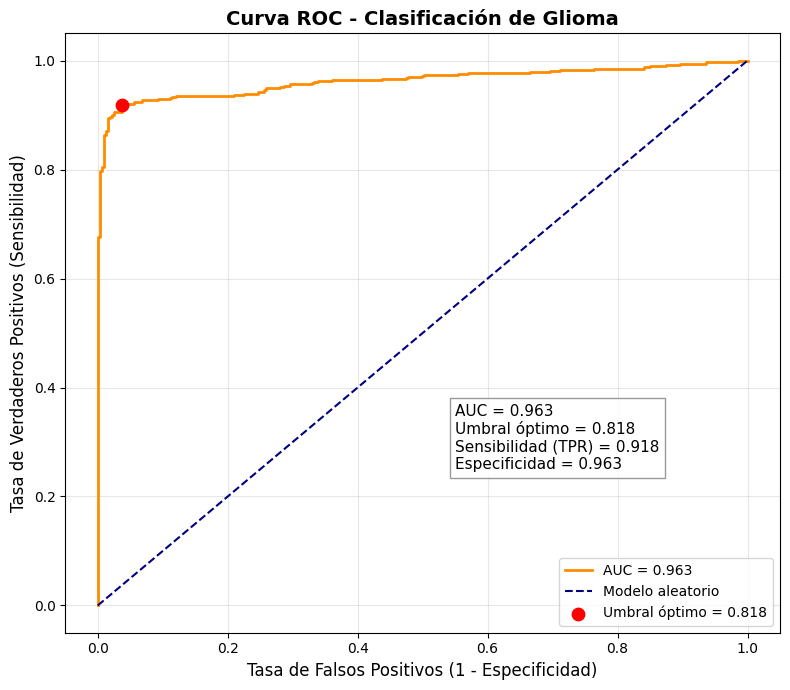

 Figura guardada como 'Curva_ROC_Glioma.png'


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

#Asegúrate de tener estos datos:
# y_true = etiquetas reales (0 o 1)
# y_pred_probs = probabilidades de salida del modelo (entre 0 y 1)

# -------------------------------
# Calcular curva ROC
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# -------------------------------
# Calcular punto óptimo (Youden's J)
# -------------------------------
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_specificity = 1 - optimal_fpr

# -------------------------------
# Graficar curva ROC
# -------------------------------
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Modelo aleatorio')

# Punto óptimo
plt.scatter(optimal_fpr, optimal_tpr, color='red', s=80, zorder=5, label=f'Umbral óptimo = {optimal_threshold:.3f}')

# Etiquetas y estilo
plt.title('Curva ROC - Clasificación de Glioma', fontsize=14, weight='bold')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

# Texto de resumen dentro de la gráfica
textstr = (
    f"AUC = {roc_auc:.3f}\n"
    f"Umbral óptimo = {optimal_threshold:.3f}\n"
    f"Sensibilidad (TPR) = {optimal_tpr:.3f}\n"
    f"Especificidad = {optimal_specificity:.3f}"
)
plt.text(0.55, 0.25, textstr, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Guardar figura en alta resolución
plt.tight_layout()
plt.savefig("Curva_ROC_Glioma.png", dpi=300)
plt.show()

print(" Figura guardada como 'Curva_ROC_Glioma.png'")


## Interpretación

**-AUC = 0.963.** Modelo sobresaliente. En términos de clasificación binaria, un AUC > 0.95 se considera excelente a nivel clínico. Esto significa que, dado un par aleatorio de imágenes (una con glioma y otra sin glioma), el modelo tiene un 96.3% de probabilidad de asignar una puntuación más alta a la imagen con glioma.

**-Umbral óptimo = 0.818.** Si el modelo predice una probabilidad > 0.818, clasifica como glioma. Es un umbral alto, lo que significa que el modelo solo clasifica como glioma cuando está muy seguro. Esto reduce falsos positivos (diagnosticar erróneamente un tumor), manteniendo aún una excelente sensibilidad.

**-Sensibilidad = 0.918.** Detecta correctamente el 91.8% de los tumores reales. Solo el 8.2% de los gliomas verdaderos pasan desapercibidos (falsos negativos). En diagnóstico médico, mantener la sensibilidad sobre 0.9 es bueno.

**-Especificidad = 0.963.** Clasifica correctamente el 96.3% de las imágenes sanas. Muy pocos falsos positivos, lo cual reduce alarmas innecesarias o sobre-diagnóstico.

In [50]:
import shutil
import os

# ---------------------------------------------------
# Configuración
# ---------------------------------------------------

# Carpeta actual (ya estás dentro de "Mini Proyectos")
carpeta_origen = "."
nombre_zip = "Mini_Proyectos_Completo"

# Ruta destino: el escritorio del usuario actual
ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")

# ---------------------------------------------------
# Crear el archivo ZIP con todo el contenido
# ---------------------------------------------------
print(" Comprimiendo carpeta actual...")
zip_path = shutil.make_archive(nombre_zip, 'zip', carpeta_origen)
print(f" Archivo ZIP creado: {zip_path}")

# ---------------------------------------------------
#  Mover el ZIP al escritorio
# ---------------------------------------------------
ruta_final = os.path.join(ruta_escritorio, os.path.basename(zip_path))
shutil.move(zip_path, ruta_final)

# ---------------------------------------------------
#  Mostrar ubicación final
# ---------------------------------------------------
print("\n Proceso completado exitosamente.")
print(f" El archivo se guardó en tu escritorio como:\n{ruta_final}")


📦 Comprimiendo carpeta actual...


RuntimeError: File size too large, try using force_zip64